# Hello World

In [4]:
println!("Hello world!");

Hello world!


# Code highlight

Code can be highlighted when exported to slides. 

In [5]:
pub struct Account {
    login: String,
    token: String
}

# Simple Rust

**Define Container**

In [6]:
use std::fmt::Debug;

#[derive(Debug)]
pub struct Container<T> {
    pub values: Vec<T>,
    pub size: usize,
}

impl<T: Default + Clone> Default for Container<T> {
  fn default() -> Self {
      let default_size = 4;
      Container{ values: vec![Default::default(); default_size], size: default_size }
  }
}

**Define a Flag**

In [7]:
#[derive(Debug, Clone)]
enum Flag {
  On,
  Off,
}

impl Default for Flag {
  fn default() -> Flag { 
      Flag::Off 
  }
}

let container = Container::<Flag>::default();
container

Container { values: [Off, Off, Off, Off], size: 4 }

**Alternative Display**

In [8]:
use std::fmt::Debug;

impl<T: Debug + Default + Clone> Container<T> {
     pub fn evcxr_display(&self) {  
        let mut html = String::new();
        html.push_str("<table>");
  
        html.push_str("<tr>");
        for c in &self.values {
                html.push_str("<td>");
                html.push_str(&format!("{:?}", c));
                html.push_str("</td>");
        }
        html.push_str("</tr>");            
     
        html.push_str("</table>");
        println!("EVCXR_BEGIN_CONTENT text/html\n{}\nEVCXR_END_CONTENT", html);
     }
}

let another_container = Container::<Flag>::default();
another_container

Off,Off,Off,Off


## Further reading

More on can be found at [evcxr_jupyter_tour](https://github.com/evcxr/evcxr/blob/main/evcxr_jupyter/samples/evcxr_jupyter_tour.ipynb)

In [10]:
:clear //clear context, skip when slides created

# Petgraph Integratinon

[Petgraph](https://crates.io/crates/petgraph) is a crate provides graph types and graph algorithms. The [petgraph-evcxr](https://github.com/timthelion/petgraph-evcxr/blob/master/README.ipynb) integrates it with Jupyter(evcxr).

## Example

**Load** `petgraph` **and** `petgraph-evcxr` **dependencies**

In [11]:
:dep petgraph = "*"
:dep petgraph-evcxr = "*"
extern crate petgraph;

**Import the libraries**

In [12]:
use petgraph::graph::Graph;
use petgraph::dot::Dot;

use petgraph::graph::UnGraph;
use petgraph::visit::NodeIndexable;
use petgraph_evcxr::{draw_graph};

**Create and draw the graph**

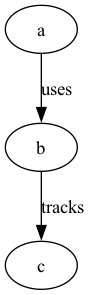

In [13]:
let mut g : Graph<&str, &str> = Graph::new();
let a = g.add_node("a");
let b = g.add_node("b");
let c = g.add_node("c");
g.add_edge(a, b, "uses");
g.add_edge(b, c, "tracks");
draw_graph(&g)

# Plotters

[Plotters](https://docs.rs/plotters/latest/plotters/) is a drawing library designed for rendering figures, plots, and charts, in pure Rust. 
It comes with a built-in support for *evcxr*.

## Example

**Add `plotters` dependency and all import the library.**

In [14]:
:dep plotters = { git = "https://github.com/38/plotters", default-features = false, features = ["evcxr", "all_series", "all_elements"] }
extern crate plotters;
use plotters::prelude::*;
use plotters::coord::Shift;
use std::error::Error;

**Create function `mk_chart` that generates the chart**

In [15]:
fn mk_chart(root: &DrawingArea<SVGBackend, Shift>) -> Result<(), Box<dyn Error>> {
      let mut chart = ChartBuilder::on(root)
          .caption("y = x^2", ("Arial", 50).into_font())
          .margin(5)
          .x_label_area_size(30)
          .y_label_area_size(30)
          .build_cartesian_2d(-1f32..1f32, -0.1f32..1f32)?;

      chart.configure_mesh().draw()?;

      chart.draw_series(LineSeries::new(
          (-50..=50).map(|x| x as f32 / 50.0).map(|x| (x, x * x)),
          &RED,
      ))?
          .label("y = x^2")
          .legend(|(x, y)| PathElement::new(vec![(x, y), (x + 20, y)], &RED));

      chart.configure_series_labels()
          .background_style(&WHITE.mix(0.8))
          .border_style(&BLACK)
          .draw()?;

      Ok(())
}

And finally draw the figure

In [16]:
let figure = evcxr_figure((640, 320), |root| {
      root.fill(&WHITE)?;
      mk_chart(&root)?;
      Ok(())
});
figure

y = x^2
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
0.0
 
 
 
0.2
 
 
 
0.4
 
 
 
0.6
 
 
 
0.8
 
 
 
1.0
 
 
 
 
-1.0
 
 
 
-0.8
 
 
 
-0.6
 
 
 
-0.4
 
 
 
-0.2
 
 
 
0.0
 
 
 
0.2
 
 
 
0.4
 
 
 
0.6
 
 
 
0.8
 
 
 
1.0
 
 
<polyline fill="none" opacity="1" stroke="#FF0000" stroke-width="1" points="35,56 40,65 46,73 52,81 58,88 64,96 70,103 76,110 82,118 88,124 94,131 100,138 106,144 112,150 118,156 124,162 130,168 136,173 142,179 148,184 154,189 160,194 166,199 172,203 178,208 184,212 190,216 196,220 202,224 208,227 214,231 220,234 226,237 232,240 238,243 244,245 250,248 256,250 262,252 268,254 274,255 280,257 286,258 292,260 298,261 304,262 310,262 316,263 322,263 328,264 334,264 340,264 346,263 352,263 358,262 364,262 370,261 376,260 382,258 388,257 394,255 400,254 406,252 412,250 418,248 424,245 430,243 436,240 442,237 448,234 454,231 460,227 466,224 472,220 478,216 484,212 490,208 496,203 502,199 508,194 514,189 520,184 526,179 532,173 538,168 544,162 550,156 556,150 562,144 568,138 574,131 580,124 586,118 592,110 598,103 604,96 610,88 616,81 622,73 628,65 634,56 "/>
 
 
 
y = x^2

# Plotty

TBD
* https://github.com/plotly/plotly.rs/blob/f7bc686fa77b56fad7b8ef9d7851a7bb96a34cc1/docs/book/src/fundamentals/jupyter_support.md?plain=1#L3
* https://github.com/plotly/plotly.rs
* https://plotly.github.io/plotly.rs/content/fundamentals/jupyter_support.html

# QRCode Generator

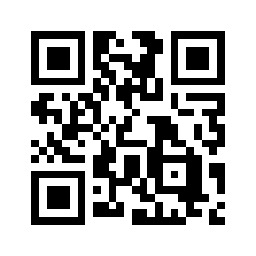

In [17]:
:dep qrcode-generator-evcxr
use qrcode_generator_evcxr::{draw_qrcode}
draw_qrcode("https://example.com");